# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?


*   Each prediction in a linear model is the result of sum of the features multiplied by weights where the weights are raised to the first power.


2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)


If there is no intercept, each dummy coefficient equals the mean target value for that category. If there is an intercept, one category is dropped as the reference group, the intercept equals that group’s mean target value, and each dummy coefficient equals the difference between that category’s mean and the reference group’s mean.


3. Can linear regression be used for classification? Explain why, or why not.

No not really. Linear regression predicts a continious numerical values. Therefore the only way you could use this for classification would be if you calculate boundaries for which values between certain numbers mean a certain category.

4. What are signs that your linear model is over-fitting?



*   It begins to fit the trainig data very closely, however performs poorly on data outside the sample. This means that the model is simply memorizing the training data rather than learning the real pattern.



5. Clearly explain multi-colinearity using the two-stage least squares technique.


*   Multicollinearity is when the input variables overlap with each other. The two stage least squares technique is when you first remove the predictor variable's that you are looking at overlap with the other variables. If little weight is left that means the variable already shared a lot with the other variables which makes it individual effect on the target variable hard to measure.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

*   You can use transformed versions of the variables such as x^2, log(x) or interaction terms like x1*x2.


7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?


*   The intercept is the predicted value of y when all the input variables are equal to 0. The slope coefficient is how much impact the variable has on the target variable. The coefficient for a dummy/one-hot-encoded variable is how much that category changes the predicted value of the target compared to the left out reference category.



**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

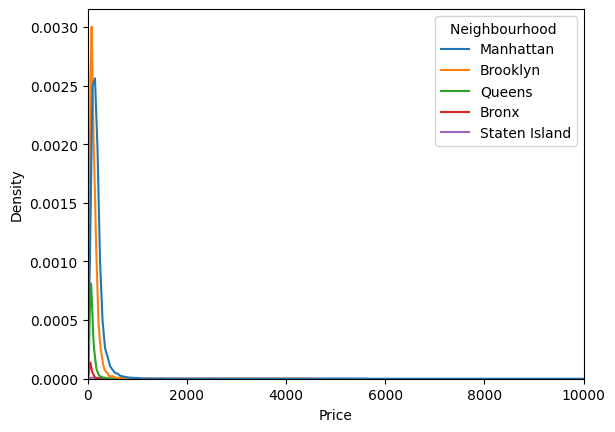

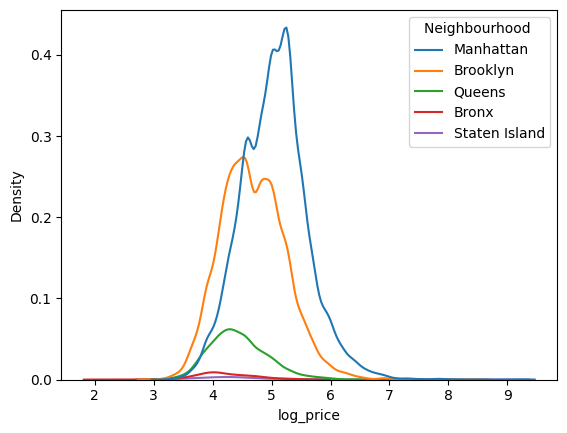

[  1.22167759 -35.94671817  14.56697484  72.26516137 -14.50733126
 -11.55671038]
[   1.04003581  -29.60421132   28.31254289   89.49634408   -4.41308886
   46.19228178   -3.50302853  -38.30253834   47.85655311  108.92997312
   58.58014624  -14.37637122  -43.49992538  -32.27608837   88.52341291
  -54.99691189   30.82201455 -137.2597105   -93.31612419   55.7526773
   57.16896875   63.95068642    6.69509283   29.23504178]


In [ ]:
#Q2 P1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Q1_clean.csv')
df.head()
df.columns

df.groupby('Neighbourhood ').mean(numeric_only = True)
#on average Manhattan is the most expensive

sns.kdeplot(data = df, x= "Price", hue = "Neighbourhood ")
plt.xlim(0, 10000)
plt.show()


df["log_price"] = np.log(df["Price"])
sns.kdeplot(data = df, x = "log_price", hue = "Neighbourhood ")
plt.show()

#Q2 P2

from sklearn.linear_model import LinearRegression

X = pd.get_dummies(df['Neighbourhood '], dtype=int)
y = df['Price']

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

model.coef_

#the coefficients for each dummy variable is the mean price of the neighborhood it represents

#Q3 P3


#we have to drop one of the dummy variables and make that the intercept
y= df['Price']
X = pd.get_dummies(df['Neighbourhood '], drop_first=True, dtype=int)

model = LinearRegression(fit_intercept=True)
model.fit(X, y)

model.coef_
model.intercept_

#the intercept is the mean of one of the neighborhoods and the coefficients are the difference between the intercept and the mean of the neighborhood the variable represents



#Q2 P4

from sklearn.model_selection import train_test_split

X = pd.get_dummies(df[['Review Scores Rating', 'Neighbourhood ']])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,)


model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

model.score(X_test, y_test)
#R^2: 0.055


from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse
#rmse: 127

print(model.coef_)
#coeff on review scores: 1.22


#Q2 P5

X = pd.get_dummies(df[['Review Scores Rating', 'Neighbourhood ', "Property Type"]])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,)


model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

model.score(X_test, y_test)
#R^2: 0.11

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse
#rmse: 103

print(model.coef_)
#coeff on review scores: 1.04


#Q2 P6
#adding property type can make the review score coefficient drop because the new variable explains some of the same price variation, meaning there is some overlap between the 2 variables.












**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

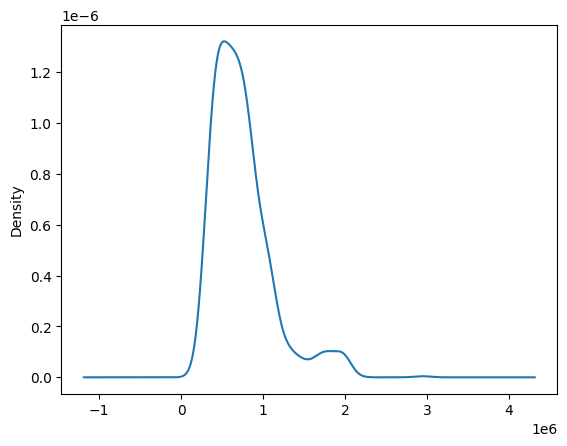

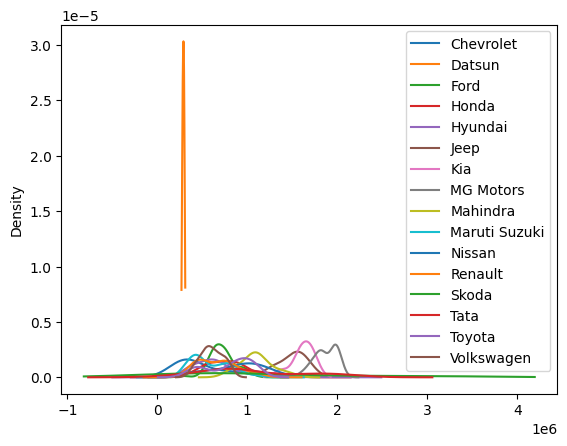

Train R2: 0.31444462126021566
Train RMSE: 309338.3729572164
Test R2: 0.29407012364751284
Test RMSE: 284546.951907215
Test R2: 0.7086843554399442
Test RMSE: 182791.1060130852
Test R2: 0.8163910583949119
Test RMSE: 145117.59426198687
Degree: 1
Train R2: 0.31444462126021566
Test R2: 0.29407012364751284
Train RMSE: 309338.3729572164
Test RMSE: 284546.951907215

Degree: 2
Train R2: 0.3482208225574098
Test R2: 0.3269110103838879
Train RMSE: 301621.8272028462
Test RMSE: 277849.3593423

Degree: 3
Train R2: 0.3405782863228277
Test R2: 0.3115419428817716
Train RMSE: 303385.0299780175
Test RMSE: 281003.61047675007

Degree: 4
Train R2: 0.3485044568320853
Test R2: 0.3078718149695556
Train RMSE: 301556.1917849117
Test RMSE: 281751.621455868

Degree: 5
Train R2: 0.34563142393152535
Test R2: 0.29111686029658446
Train RMSE: 302220.3772928611
Test RMSE: 285141.5329357044

Degree: 6
Train R2: 0.3461292590867485
Test R2: 0.2935360229194516
Train RMSE: 302105.3927405257
Test RMSE: 284654.5744941421

Degree

In [ ]:
#Q3 P1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/cars_hw.csv")

df.head()

df[["Make_Year", "Mileage_Run", "Seating_Capacity", "Price"]].describe()


#Q3 P2

df["Price"].describe()

df["Price"].plot(kind="kde")
plt.show()

df.groupby("Make")["Price"].describe()

for make, group in df.groupby("Make"):
    group["Price"].plot(kind="kde", label=make)

plt.legend()
plt.show()
df.groupby("Make")["Price"].describe().sort_values("mean", ascending=False)

#Which car brands are the most expensive? What do prices look like in general?
#MG motors. In general prices are right skewed, so most cars are clustered between low and middle prices

#Q3 P3
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2)


#Q3 P4


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np


#regression on numerical
X = df[["Make_Year", "Mileage_Run", "Seating_Capacity"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)

print("Train R2:", r2_score(y_train, model.predict(X_train)))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, model.predict(X_train))))
print("Test R2:", r2_score(y_test, model.predict(X_test)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, model.predict(X_test))))

#regression on categorical
X = pd.get_dummies(df[["Make", "Color", "Body_Type", "No_of_Owners", "Fuel_Type", "Transmission", "Transmission_Type"]], drop_first=True)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)

print("Test R2:", r2_score(y_test, model.predict(X_test)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, model.predict(X_test))))

# Categorical variables perform better as the R^2 value is higher and the RMSE is lower on the test set.

X = pd.get_dummies(df.drop("Price", axis=1), drop_first=True)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)

print("Test R2:", r2_score(y_test, model.predict(X_test)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, model.predict(X_test))))

#the model performs better when numerical and categorical variables are joined. The R^2 is at least 0.1 higher than both numerical and categorical and the RMSE is lower than both categorical and numerical as well.


#Q3 P5
from sklearn.preprocessing import PolynomialFeatures

X = df[["Make_Year", "Mileage_Run", "Seating_Capacity"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for d in range(1, 20):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression().fit(X_train_poly, y_train)

    train_r2 = r2_score(y_train, model.predict(X_train_poly))
    test_r2 = r2_score(y_test, model.predict(X_test_poly))
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_poly)))

    print("Degree:", d)
    print("Train R2:", train_r2)
    print("Test R2:", test_r2)
    print("Train RMSE:", train_rmse)
    print("Test RMSE:", test_rmse)
    print()

    #The model works best at degree = 2, with a steady decrease in the test R^2 with it becoming negative at degree = 17
    #The best degree works similiary to the numerical regression



  #Q3 P6





**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.